In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
data = pd.read_csv("data.csv")
data.shape


(160, 8)

In [43]:
data.head()


,event_id,date,event_type,topic,attendance,duration_hours,feedback_rating,difficulty
0,1,2025-01-05,Workshop,web development,40,2.0,4.1,2
1,2,2025-01-07,Workshop,machine learning,35,2.5,4.4,4
2,3,2025-01-09,Talk,quantum computing,20,1.5,3.6,5
3,4,2025-01-11,Workshop,generative AI,45,2.0,4.6,3
4,5,2025-01-13,Contest,web development,55,3.0,4.2,3


In [44]:
data.dtypes


event_id             int64
date                   str
event_type             str
topic                  str
attendance           int64
duration_hours     float64
feedback_rating    float64
difficulty           int64
dtype: object

#### **Q1 | Topic event counts:** each of them equal 40

In [48]:
topic_counts = data["topic"].value_counts()
print("Q1 --> Topic event counts: \n", topic_counts)

Q1 --> Topic event counts: 
 topic
web development      40
machine learning     40
quantum computing    40
generative AI        40
Name: count, dtype: int64


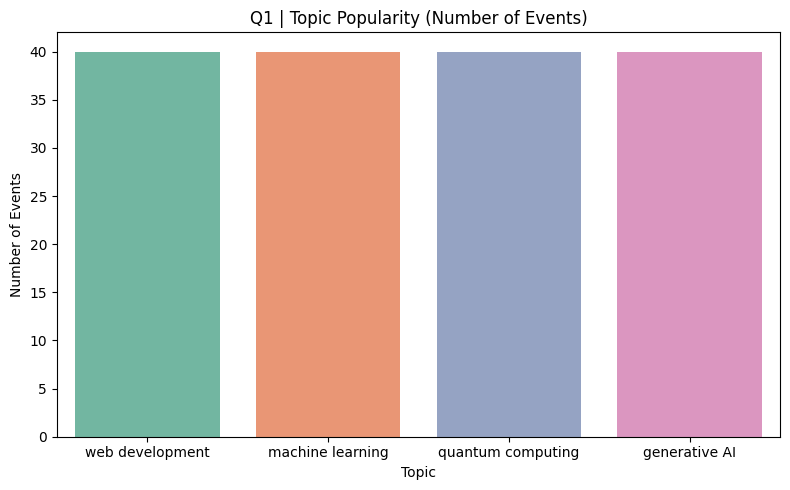

In [54]:
plt.figure(figsize=(8,5))
sns.barplot(x=topic_counts.index, y=topic_counts.values, hue=topic_counts.index, palette="Set2", legend=False)
plt.title("Q1 | Topic Popularity (Number of Events)")
plt.xlabel("Topic")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.show()

#### **Q2 | Which events attract the highest attendance?**  Workshops

In [61]:
high_att = data.groupby("event_type")["attendance"].sum().sort_values(ascending=False)
print("Q2 --> Sum of attendance by event type:")
high_att

Q2 --> Sum of attendance by event type:


event_type
Workshop    7049
Contest     4092
Talk        1581
Name: attendance, dtype: int64

Text(0.5, 1.0, 'Attendance by event type')

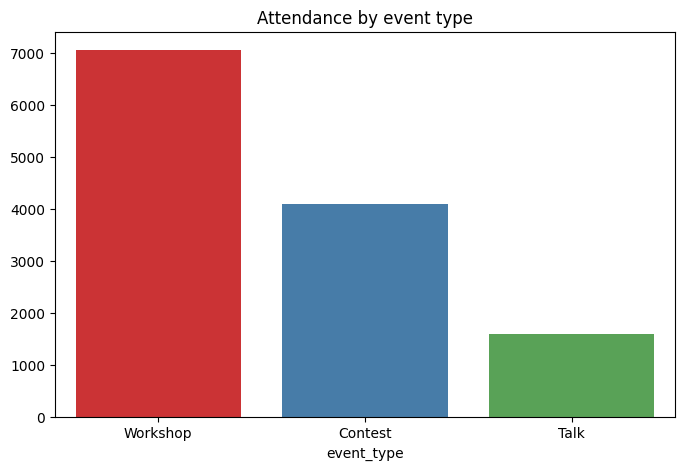

In [67]:
plt.figure(figsize=(8,5))
sns.barplot(x=high_att.index, y=high_att.values, hue=high_att.index, palette="Set1")
plt.title("Attendance by event type")

#### **Q3 | Which events are rated the best?** Workshops also

In [68]:
rating_event = data.groupby("event_type")["feedback_rating"].mean().sort_values(ascending=False)
print("Q3 --> Average of rating by event type: \n", rating_event)


Q3 --> Average of rating by event type: 
 event_type
Workshop    4.908642
Contest     4.869231
Talk        4.197500
Name: feedback_rating, dtype: float64


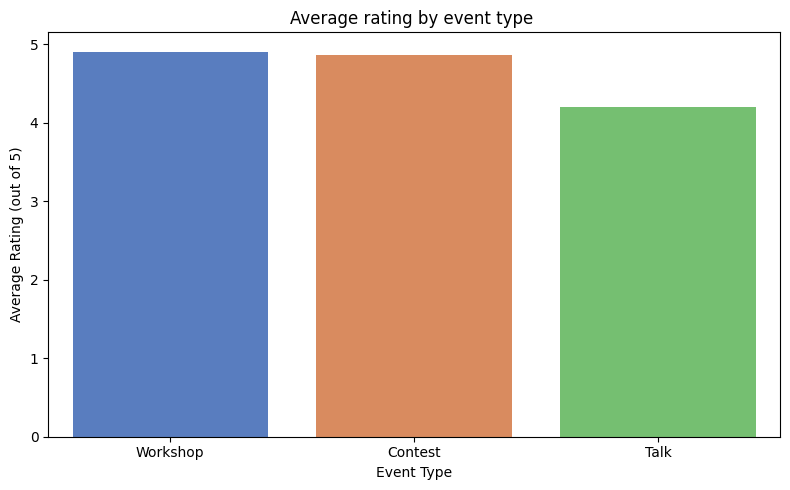

In [71]:
plt.figure(figsize=(8,5))
sns.barplot(x=rating_event.index, y=rating_event.values, hue=rating_event.index, palette="muted")
plt.title("Average rating by event type ")
plt.xlabel("Event Type")
plt.ylabel("Average Rating (out of 5)")
plt.tight_layout()

#### **Q5 | Is there a pattern between difficulty and rating?** Yes 0.6 negative, when difficulty increases the rate decreases.

In [76]:
print("Q4 - Correlation difficulty vs rating: ", data["difficulty"].corr(data["feedback_rating"]))

Q4 - Correlation difficulty vs rating:  -0.6423062362256706


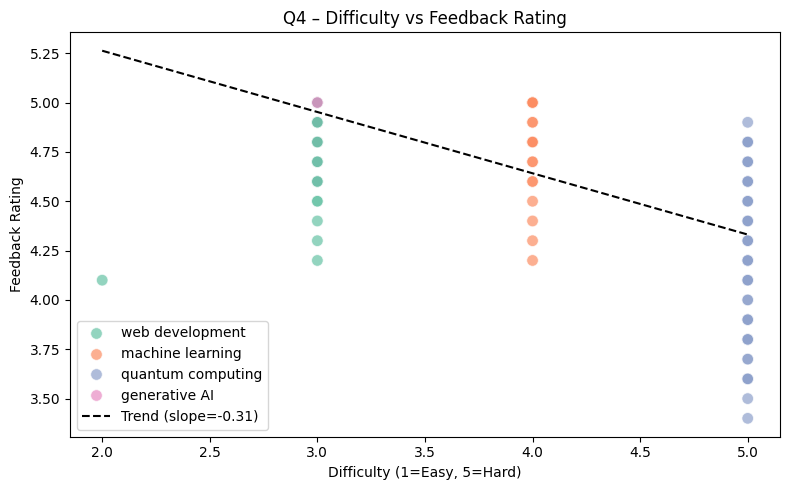

In [109]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="difficulty", y="feedback_rating",
                hue="topic", palette="Set2", s=70, alpha=0.7)
# add a trend line using numpy
m, b = np.polyfit(data["difficulty"], data["feedback_rating"], 1)
x_vals = np.array([data["difficulty"].min(), data["difficulty"].max()])
plt.plot(x_vals, m * x_vals + b, color="black", linestyle="--", label=f"Trend (slope={m:.2f})")
plt.title("Q4 – Difficulty vs Feedback Rating")
plt.xlabel("Difficulty (1=Easy, 5=Hard)")
plt.ylabel("Feedback Rating")
plt.legend()
plt.tight_layout()
plt.show()
 

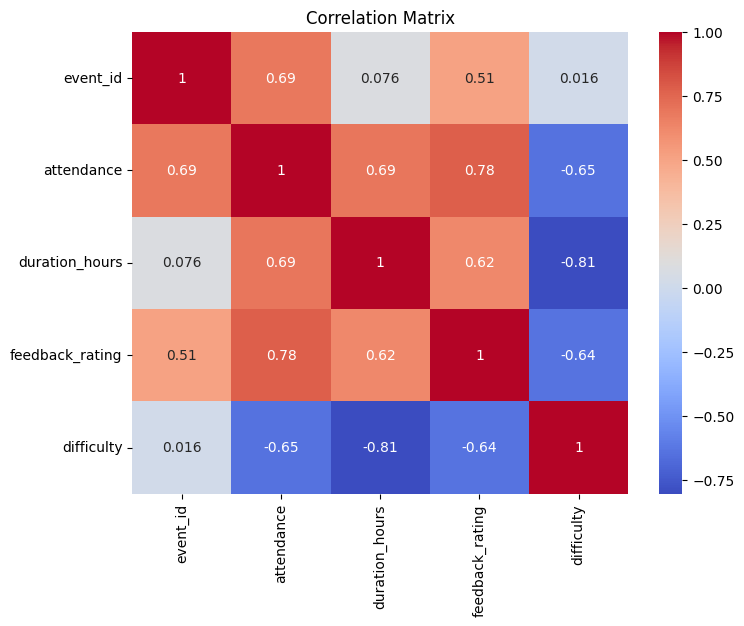

In [83]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

#### **Q6 – Which attracts more students, longer or shorter events?** Longer contains more attendees.

In [84]:
print("Q6 – Correlation between attendance vs duration: ", data['duration_hours'].corr(data["attendance"]))

Q6 – Correlation between attendance vs duration:  0.6922022991002107


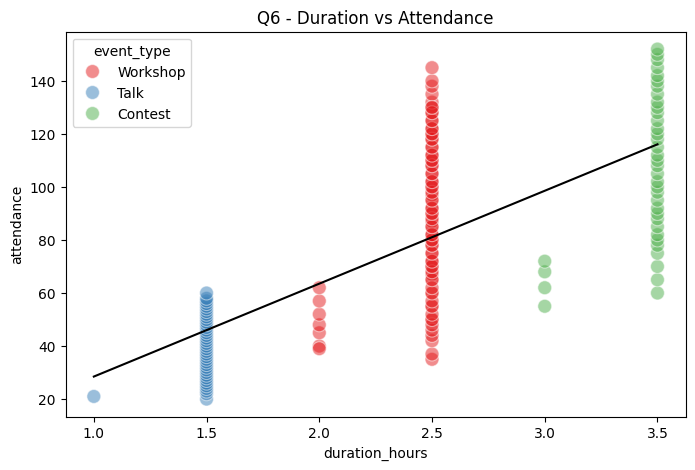

In [92]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x="duration_hours", y="attendance", hue="event_type", palette="Set1", s=100, alpha=0.5)
plt.title("Q6 - Duration vs Attendance")
n,c= np.polyfit(data["duration_hours"], data["attendance"], 1)
x2 = np.array([data["duration_hours"].min(), data["duration_hours"].max()])
plt.plot(x2, n * x2 + c, color="black", linestyle="-", label=f"Trend (slope={n:.1f})")


#### **Q7 – Which topic is the most attended?** Web Development

In [93]:
average_attPerTopic = data.groupby("topic")["attendance"].mean().sort_values(ascending=False)
print("Q7 - Average attendance per topic: ", average_attPerTopic)

Q7 - Average attendance per topic:  topic
web development      103.300
generative AI         93.725
machine learning      81.500
quantum computing     39.525
Name: attendance, dtype: float64


Text(58.347222222222214, 0.5, 'Average Attendance')

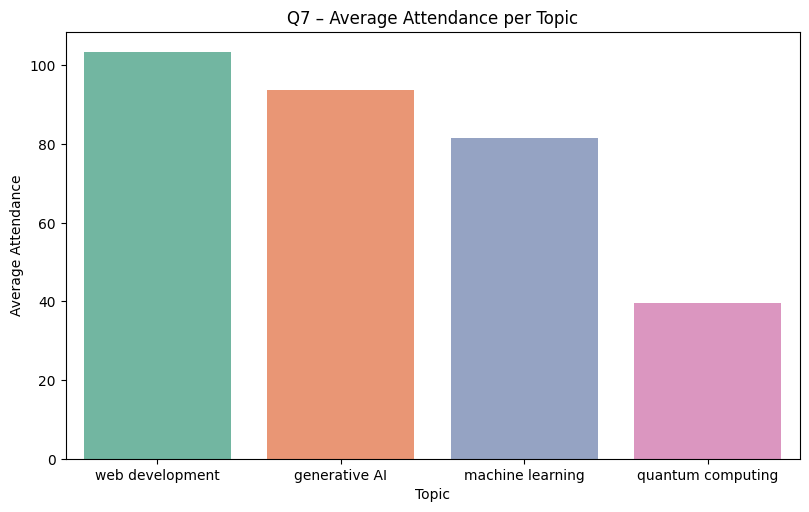

In [96]:
plt.figure(figsize=(8,5))
sns.barplot(x=average_attPerTopic.index, y=average_attPerTopic.values, hue=average_attPerTopic.index, palette="Set2")
plt.tight_layout()
plt.title("Q7 – Average Attendance per Topic")
plt.xlabel("Topic")
plt.ylabel("Average Attendance")

#### **Q8 – Which topic is most liked? (highest rating)**? generative AI 

In [97]:
average_rate_topic = data.groupby("topic")["feedback_rating"].mean().sort_values(ascending=False)
print("Q8 - Average rating by topic: ", average_rate_topic)

Q8 - Average rating by topic:  topic
generative AI        4.9575
machine learning     4.8800
web development      4.8500
quantum computing    4.1975
Name: feedback_rating, dtype: float64


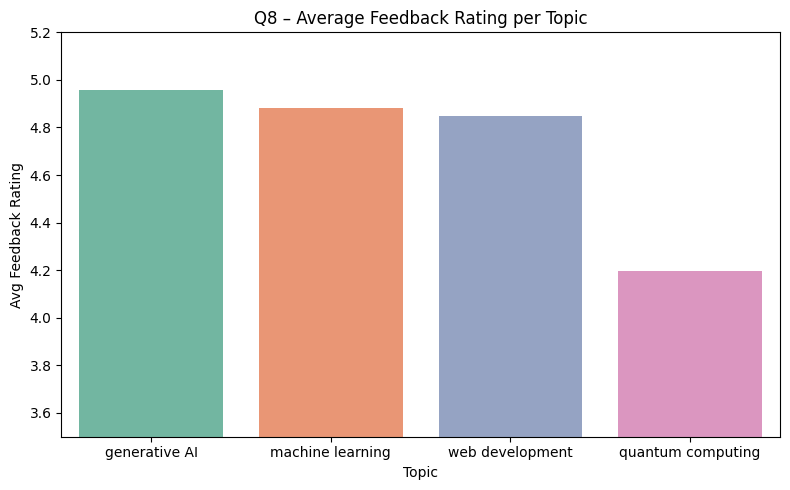

In [101]:
plt.figure(figsize=(8, 5))
sns.barplot(x=average_rate_topic.index, y=average_rate_topic.values,
            hue=average_rate_topic.index, palette="Set2", legend=False)
plt.title("Q8 – Average Feedback Rating per Topic")
plt.xlabel("Topic")
plt.ylabel("Avg Feedback Rating")
plt.ylim(3.5, 5.2)
plt.tight_layout()

#### **Q9 – Which topic is most efficient? (attendance per hour)** generative AI 

In [103]:
data["attendance_per_hour"] = data["attendance"] / data["duration_hours"]
efficiency = data.groupby("topic")["attendance_per_hour"].mean().sort_values(ascending=False)
print("Q9 – Attendance per hour by topic:", efficiency)

Q9 – Attendance per hour by topic: topic
generative AI        38.150000
machine learning     32.697500
web development      30.034524
quantum computing    26.525000
Name: attendance_per_hour, dtype: float64


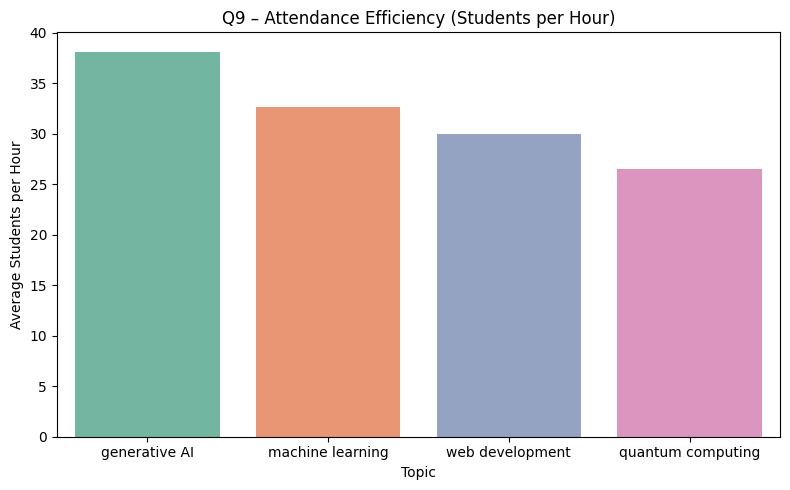

In [105]:
plt.figure(figsize=(8,5))
sns.barplot(x=efficiency.index, y=efficiency.values, hue=efficiency.index, palette="Set2")
plt.title("Q9 – Attendance Efficiency (Students per Hour)")
plt.xlabel("Topic")
plt.ylabel("Average Students per Hour")
plt.tight_layout()

#### BONUS – Attendance trend over time

In [107]:
data["date"] = pd.to_datetime(data["date"])
data=data.sort_values("date")

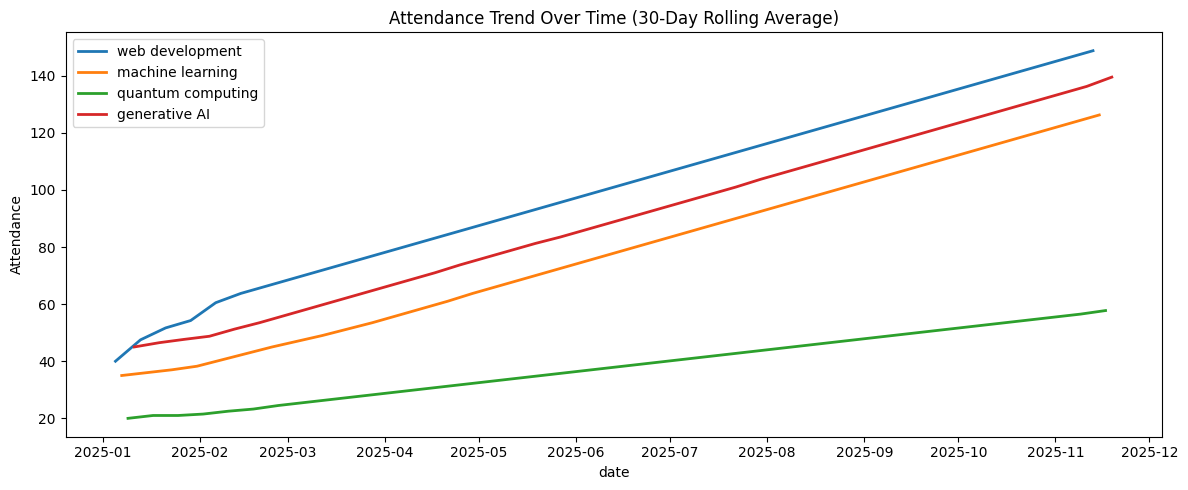

In [108]:
plt.figure(figsize=(12,5))
for topic in data["topic"].unique():
    subset = data[data["topic"] == topic]
    rolling = subset.set_index("date")["attendance"].rolling("30D").mean()
    plt.plot(rolling.index, rolling.values, label=topic, linewidth=2)

plt.title("Attendance Trend Over Time (30-Day Rolling Average)")
plt.xlabel("date")
plt.ylabel("Attendance")
plt.legend()
plt.tight_layout()